# ☕ Coffee Flavor DNA — Recommendation & Visualization

**Dataset**: [Kaggle — Coffee Reviews (1997–2025)](https://www.kaggle.com/datasets/xinowo/coffee-reviews-feb-1997-mar-2025?select=coffee_reviews_parsed.csv)

This notebook builds a flavor-based similarity & recommendation system, and visualizes global coffee structure.


In [1]:
# Step 0. Imports & Options
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# (optional) pretty printing
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


## Step 1. Load the dataset

We use a dataset parsed from **CoffeeReview.com**, containing cupping scores (aroma, acidity, body, flavor, aftertaste),  
together with metadata such as origin, roast level, and Agtron roast color values.

In [5]:
# Load dataset
df = pd.read_csv("../data/coffee_ultimato.csv")

# Preview the first rows
df.head()

,URL,Rating,Roaster,Coffee Name,Roaster Location,Coffee Origin,Aroma,Acidity,Acidity/Structure,Body,Flavor,Aftertaste,With Milk,Blind Assessment,Notes,Who Should Drink It,Bottom Line,Agtron_whole,Agtron_ground,Roaster Latitude,Roaster Longitude,usd_per_100g_adj,coffee_origin_adj,roast_lv_adj,coffee_name_hundredpercent,review_date_adj
0,https://www.coffeereview.com/review/100-arabic...,89.0,Caffe Bomrad,100% Arabica 100% Italiano,"Torino, Italy",Not disclosed.,8.0,NaN,NaN,8.0,8.0,7.0,8.0,Evaluated as espresso. Smoothly round aroma: t...,Roasted in Northern Italy and distributed in N...,A strong-charactered Northern Italian styled e...,NaN,48.0,65.0,45.070315,7.686855,7.548955,NaN,3.0,True,2011-11-01
1,https://www.coffeereview.com/review/100-arabic...,87.0,Lucaff?,"100% Arabica, Black Label (ESE pod)","Padenghe sul Garda, Italy",Not disclosed.,7.0,NaN,NaN,8.0,7.0,7.0,8.0,Produced from an ESE pod on a FrancisFrancis! ...,ESE (Easy Serving Espresso) pods are wafer-lik...,An attractive pod espresso for big milk drinks.,NaN,0.0,80.0,45.495816,10.511448,NaN,NaN,5.0,True,2009-01-01
2,https://www.coffeereview.com/review/100-arabic...,87.0,Caribeans,100% Arabica Coffee from Puerto Rico,"San Juan, Puerto Rico","Utuado, central Puerto Rico",8.0,7.0,NaN,7.0,8.0,7.0,NaN,Bittersweet but balanced; chocolaty. Dark choc...,Produced on a single farm in the central mount...,NaN,Satisfying chocolate and nut notes nearly carr...,54.0,69.0,18.454191,-66.070583,9.615077,peurto rico,2.0,True,2017-05-01
3,https://www.coffeereview.com/review/100-arabic...,88.0,Waka Coffee,100% Arabica Freeze-Dried Colombian (Instant C...,"Los Angeles, California",Colombia,7.0,NaN,7.0,8.0,8.0,8.0,NaN,Evaluated at proportions of 5 grams of instant...,The green coffee for this product was produced...,NaN,A appealing 100% Colombia coffee in instant fo...,0.0,0.0,34.054908,-118.242643,5.733532,colombia,NaN,True,2018-11-01
4,https://www.coffeereview.com/review/100-arabic...,72.0,Yuban,100% Arabica Instant Coffee,"Northfield, Illinois",Colombia. All coffee of the Arabica species.,4.0,4.0,NaN,7.0,3.0,4.0,NaN,In the aroma caramel and wet burned wood notes...,An instant coffee evaluated as mixed in propor...,"Not good, but not the worst of the instants on...",NaN,0.0,0.0,42.099750,-87.780897,5.097570,colombia,NaN,True,2011-03-01


In [6]:
pd.set_option("display.max_columns", None)
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8387 entries, 0 to 8386
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   URL                         8387 non-null   object 
 1   Rating                      8382 non-null   float64
 2   Roaster                     8382 non-null   object 
 3   Coffee Name                 8382 non-null   object 
 4   Roaster Location            8283 non-null   object 
 5   Coffee Origin               7815 non-null   object 
 6   Aroma                       8220 non-null   float64
 7   Acidity                     3708 non-null   float64
 8   Acidity/Structure           3270 non-null   float64
 9   Body                        8271 non-null   float64
 10  Flavor                      8267 non-null   float64
 11  Aftertaste                  7413 non-null   float64
 12  With Milk                   1145 non-null   float64
 13  Blind Assessment            8376 

## Step 2. Basic cleaning & feature prep

- Merge acidity fields → `Acidity_final`
- Average Agtron readings → `Agtron_final`
- Normalize origins; fill missing with `"Unknown"` and add `continent`


In [7]:
# 2.1 Core fields sanity
for c in ["Aroma","Acidity","Acidity/Structure","Body","Flavor","Aftertaste","Rating","roast_lv_adj","Agtron_whole","Agtron_ground","coffee_origin_adj"]:
    if c not in df.columns:
        print("Missing column:", c)

# 2.2 Create final acidity and agtron
df["Acidity_final"] = df["Acidity"].fillna(df["Acidity/Structure"])
df["Agtron_final"]  = df[["Agtron_whole","Agtron_ground"]].mean(axis=1)

# 2.3 Origin cleaning
df["coffee_origin_adj"] = (
    df["coffee_origin_adj"]
    .replace({"peurto rico":"puerto rico"})
    .fillna("Unknown")
    .str.lower().str.strip()
)

# 2.4 Map to continent
continent_map = {
    # Africa
    "ethiopia":"Africa","kenya":"Africa","tanzania":"Africa","rwanda":"Africa","burundi":"Africa","uganda":"Africa","congo":"Africa","zimbabwe":"Africa","zambia":"Africa",
    # Central America
    "guatemala":"Central America","honduras":"Central America","nicaragua":"Central America","costa rica":"Central America","panama":"Central America","salvador":"Central America",
    # South America
    "colombia":"South America","peru":"South America","ecuador":"South America","bolivia":"South America","brazil":"South America",
    # North America / Caribbean
    "mexico":"North America","united states":"North America","hawaii":"North America",
    "puerto rico":"Caribbean","jamaica":"Caribbean","haiti":"Caribbean","dominican republic":"Caribbean",
    # Asia / Middle East / Oceania
    "indonesia":"Asia","thailand":"Asia","philippines":"Asia","taiwan":"Asia","china":"Asia","india":"Asia","vietnam":"Asia","yemen":"Middle East",
    "australia":"Oceania",
    # misc
    "others":"Other","unknown":"Unknown"
}
def map_continent(x): return continent_map.get(str(x).lower().strip(), "Other")
df["continent"] = df["coffee_origin_adj"].apply(map_continent)

df[["coffee_origin_adj","continent"]].head(10)


,coffee_origin_adj,continent
0,unknown,Unknown
1,unknown,Unknown
2,puerto rico,Caribbean
3,colombia,South America
4,colombia,South America
5,colombia,South America
6,colombia,South America
7,colombia,South America
8,others,Other
9,colombia,South America


## Step 3. Flavor-only vs Enriched feature spaces

- **Flavor**: `[Aroma, Acidity_final, Body, Flavor, Aftertaste]`
- **Meta**: `[Rating, roast_lv_adj, Agtron_final]`
- **Origin**: one-hot on `coffee_origin_adj` (or `continent`, choose one)

We z-score each block separately, apply weights, and compute cosine similarity.


In [8]:
# 3.1 Flavor block
FLAVOR_COLS = ["Aroma","Acidity_final","Body","Flavor","Aftertaste"]
flavor_block = df[FLAVOR_COLS].copy()
flavor_block = flavor_block.fillna(flavor_block.median(numeric_only=True))
Z_f = StandardScaler().fit_transform(flavor_block.values)
sim_flavor = cosine_similarity(Z_f); np.fill_diagonal(sim_flavor, 0)

# 3.2 Enriched block
meta_cols = ["Rating","roast_lv_adj","Agtron_final"]
meta_block = df[meta_cols].fillna(df[meta_cols].median(numeric_only=True))
origin_block = pd.get_dummies(df["coffee_origin_adj"], prefix="origin")  # or use df["continent"]

Z_m = StandardScaler().fit_transform(meta_block.values)
Z_r = StandardScaler().fit_transform(origin_block.values.astype(float))

LAMBDA_FLAVOR, LAMBDA_META, LAMBDA_REGION = 1.0, 0.4, 0.3  # you can tune
G = np.hstack([Z_f*LAMBDA_FLAVOR, Z_m*LAMBDA_META, Z_r*LAMBDA_REGION])
sim_enriched = cosine_similarity(G); np.fill_diagonal(sim_enriched, 0)

Z_f.shape, G.shape


((8387, 5), (8387, 46))

## Step 4. Recommendation helpers


In [9]:
def find_coffee_indices(name_keyword, roaster_keyword=None, top=10):
    name_kw = str(name_keyword).lower()
    name_mask = df["Coffee Name"].astype(str).str.lower().str.contains(name_kw, na=False)
    if roaster_keyword:
        roast_kw = str(roaster_keyword).lower()
        roaster_mask = df["Roaster"].astype(str).str.lower().str.contains(roast_kw, na=False)
        mask = name_mask & roaster_mask
    else:
        mask = name_mask
    idxs = df.index[mask].tolist()
    return idxs[:top]

def neighbors(sim, i, k=5):
    s = sim[i].copy()
    order = np.argsort(s)[::-1]
    order = order[order != i][:k]
    return order

def recommend_table(idxs):
    cols = ["Roaster","Coffee Name","coffee_origin_adj","continent","Rating","roast_lv_adj"]
    out = df.loc[idxs, cols].copy()
    return out


## Step 5. Example — Flavor-only vs Enriched


In [10]:
# pick a reference coffee (change keyword to your demo coffee, e.g., "santos")
cand = find_coffee_indices("santos")
assert len(cand)>0, "No coffee matched keyword"
i = cand[0]

nbr_f = neighbors(sim_flavor, i, k=5)
nbr_e = neighbors(sim_enriched, i, k=5)

print("Reference:")
display(df.loc[[i], ["Roaster","Coffee Name","coffee_origin_adj","continent","Rating","roast_lv_adj"]])

print("\nFlavor-only Recommendations")
display(recommend_table(nbr_f))

print("\nEnriched Recommendations")
display(recommend_table(nbr_e))


Reference:


,Roaster,Coffee Name,coffee_origin_adj,continent,Rating,roast_lv_adj
195,Podhead,Arabica Express Sensation Brasil Santos,brazil,South America,85.0,NaN



Flavor-only Recommendations


,Roaster,Coffee Name,coffee_origin_adj,continent,Rating,roast_lv_adj
7091,Sudden Coffee,Rayos del Sol Peru Light Roast (Instant Coffee),peru,South America,84.0,1.0
1884,Starbucks Reserve Roastery,Decaf Pike Place Roast,costa rica,Central America,84.0,5.0
48,Bay View Farm,100% Kona Peaberry Dark Roast,hawaii,North America,85.0,4.0
7421,Gevalia Kaffe,Signature Blend (K-Cup),unknown,Unknown,84.0,6.0
19,Brown Gold,100% Ethiopian (K-Cup),ethiopia,Africa,84.0,6.0



Enriched Recommendations


,Roaster,Coffee Name,coffee_origin_adj,continent,Rating,roast_lv_adj
617,St. Ives Coffee Roasters,Brazilian,brazil,South America,84.0,6.0
6550,Golden Ratio,Original Gold Coffee Pouches,ethiopia,Africa,80.0,NaN
3809,Flavia,French Roast,colombia,South America,83.0,NaN
1477,Flavia,Colombia,colombia,South America,81.0,NaN
764,Melitta,Cafe Kind of Day 100% Colombian,colombia,South America,73.0,NaN


## Step 6. Radar chart — Flavor DNA comparison


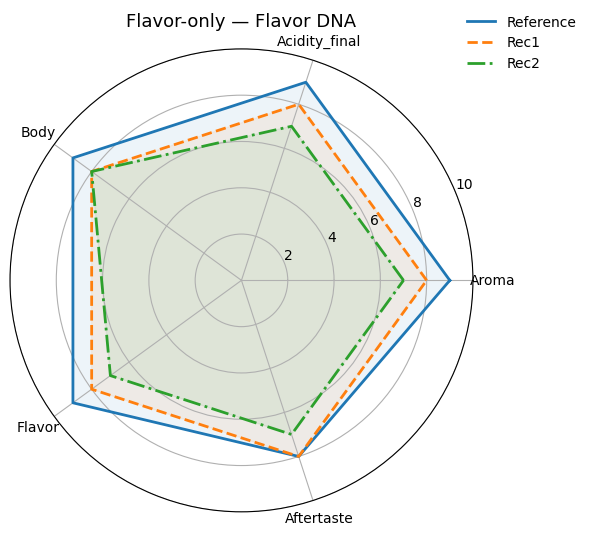

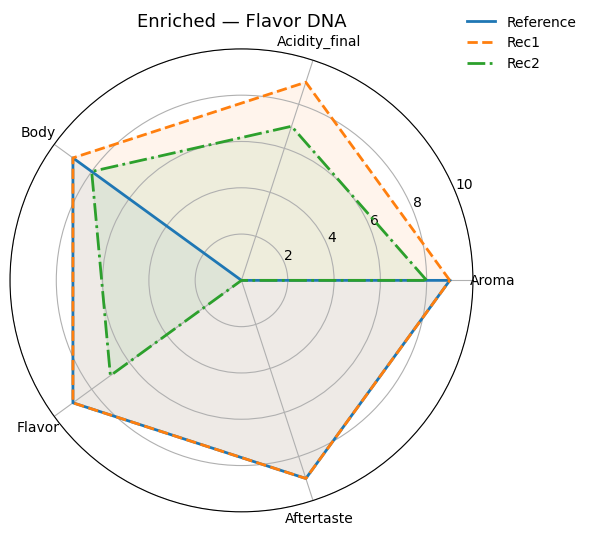

In [18]:
def plot_radar(coffee_indices, labels=None, title="Flavor DNA"):
    feats = FLAVOR_COLS
    n = len(feats)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
    angles.append(angles[0])

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728"]
    styles  = ["solid","dashed","dashdot","dotted"]

    for idx, ci in enumerate(coffee_indices):
        vals = df.loc[ci, feats].astype(float).values
        vals = np.nan_to_num(vals).tolist()
        vals.append(vals[0])
        label = labels[idx] if labels and idx < len(labels) else f"#{ci}"
        ax.plot(angles, vals, linewidth=2, color=colors[idx%4], linestyle=styles[idx%4], label=label)
        ax.fill(angles, vals, alpha=0.08, color=colors[idx%4])

    ax.set_xticks(angles[:-1]); ax.set_xticklabels(feats)
    ax.set_rlim(0, 10)
    ax.set_title(title, fontsize=13)
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), frameon=False)
    plt.tight_layout()
    return fig

# draw two charts and save
fig1 = plot_radar([i] + neighbors(sim_flavor, i, 3), ["Reference","Rec1","Rec2","Rec3"], "Flavor-only — Flavor DNA")
fig1.savefig("../outputs/radar_flavor.png", dpi=160)

fig2 = plot_radar([i] + neighbors(sim_enriched, i, 3), ["Reference","Rec1","Rec2","Rec3"], "Enriched — Flavor DNA")
fig2.savefig("../outputs/radar_enriched.png", dpi=160)
plt.show()


## Step 7. PCA flavor maps — side by side


/var/folders/04/rs7rc_n15rl_bkvq74vv7l2m0000gn/T/ipykernel_34920/146968701.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(cats))
/var/folders/04/rs7rc_n15rl_bkvq74vv7l2m0000gn/T/ipykernel_34920/146968701.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(cats))


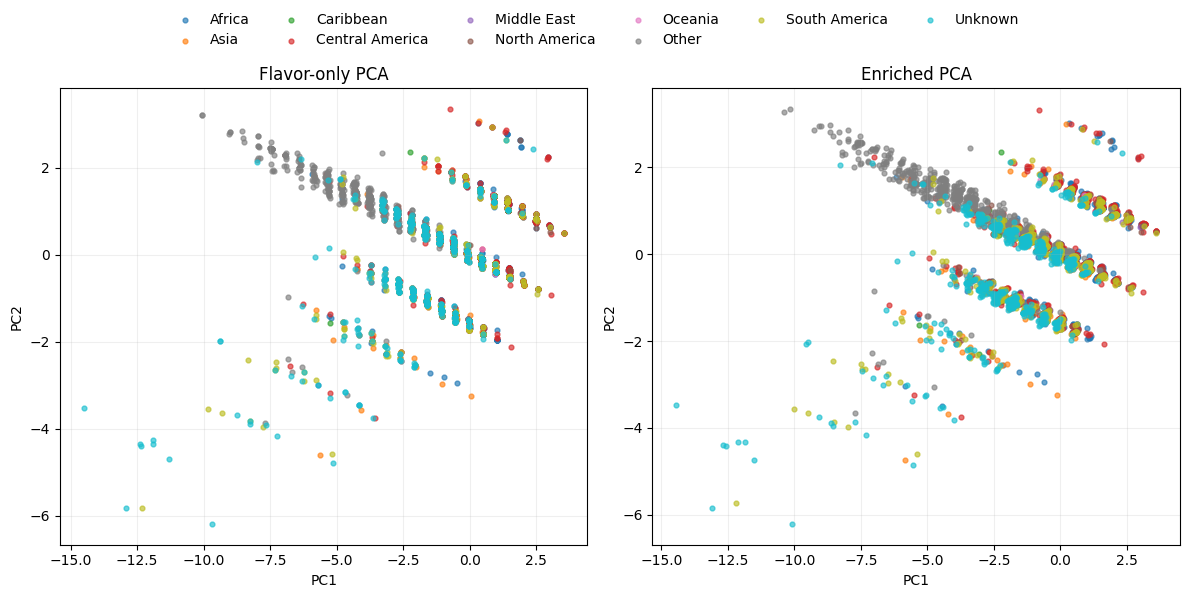

In [13]:
# build embeddings
pca_f = PCA(n_components=2, random_state=42).fit_transform(Z_f)
pca_e = PCA(n_components=2, random_state=42).fit_transform(G)

df_embed = pd.DataFrame({
    "x_f": pca_f[:,0], "y_f": pca_f[:,1],
    "x_e": pca_e[:,0], "y_e": pca_e[:,1],
    "continent": df["continent"].values
})

# plot
fig, axes = plt.subplots(1,2, figsize=(12,6))
for ax, x, y, title in [(axes[0],"x_f","y_f","Flavor-only PCA"), (axes[1],"x_e","y_e","Enriched PCA")]:
    cats = pd.Categorical(df_embed["continent"]).categories
    cmap = plt.cm.get_cmap("tab10", len(cats))
    for ci, c in enumerate(cats):
        m = df_embed["continent"]==c
        ax.scatter(df_embed.loc[m,x], df_embed.loc[m,y], s=12, alpha=0.65, color=cmap(ci), label=c)
    ax.set_title(title); ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.grid(True, alpha=0.2)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(6, len(labels)), frameon=False)
plt.tight_layout(rect=[0,0,1,0.92])
plt.savefig("../outputs/pca_flavor_vs_enriched.png", dpi=180)
plt.show()


## Step 8. (Optional) t-SNE / UMAP for smoother clusters


/var/folders/04/rs7rc_n15rl_bkvq74vv7l2m0000gn/T/ipykernel_34920/4224101700.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(cats))
/var/folders/04/rs7rc_n15rl_bkvq74vv7l2m0000gn/T/ipykernel_34920/4224101700.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(cats))


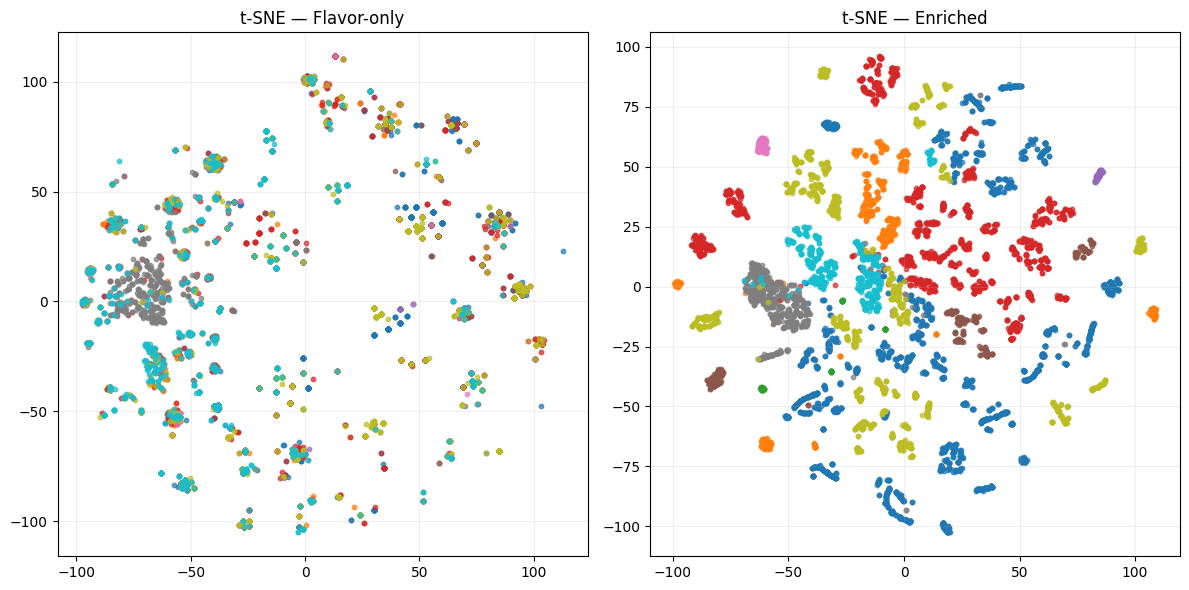

In [15]:
# t-SNE (sklearn >= 1.2: use max_iter)
from sklearn.manifold import TSNE
pca50_f = PCA(n_components=min(50, Z_f.shape[1]), random_state=42).fit_transform(Z_f)
pca50_e = PCA(n_components=min(50, G.shape[1]),   random_state=42).fit_transform(G)

tsne_f = TSNE(n_components=2, perplexity=30, learning_rate=200, init="pca", max_iter=1000, random_state=42, verbose=0)
tsne_e = TSNE(n_components=2, perplexity=30, learning_rate=200, init="pca", max_iter=1000, random_state=42, verbose=0)
xy_tsne_f = tsne_f.fit_transform(pca50_f)
xy_tsne_e = tsne_e.fit_transform(pca50_e)

fig, axes = plt.subplots(1,2, figsize=(12,6))
for ax, XY, title in [(axes[0], xy_tsne_f, "t-SNE — Flavor-only"), (axes[1], xy_tsne_e, "t-SNE — Enriched")]:
    cats = pd.Categorical(df["continent"]).categories
    cmap = plt.cm.get_cmap("tab10", len(cats))
    for ci, c in enumerate(cats):
        m = (df["continent"]==c).values
        ax.scatter(XY[m,0], XY[m,1], s=10, alpha=0.7, color=cmap(ci), label=c)
    ax.set_title(title); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("../outputs/tsne_flavor_vs_enriched.png", dpi=180)
plt.show()


## Step 9. Similarity network (enriched)

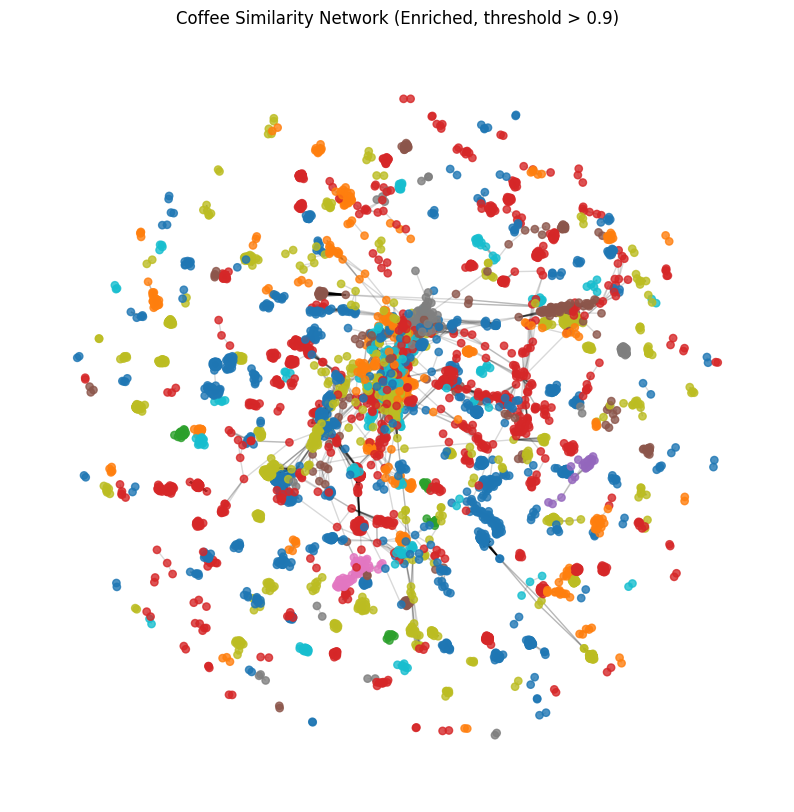

Graph — nodes: 8147, edges: 238088


In [19]:
# Build graph from enriched similarity (thresholded)
import networkx as nx

sim = sim_enriched
thr = 0.9

edges = []
n = sim.shape[0]
for a in range(n):
    # sparse edge build
    rows = np.where(sim[a] > thr)[0]
    for b in rows:
        if b > a:
            edges.append((a, b, sim[a, b]))

G = nx.Graph()
G.add_weighted_edges_from(edges)

# draw
plt.figure(figsize=(10,10))
pos = nx.spring_layout(G, k=0.15, seed=42)
node_colors = df.loc[list(G.nodes), "continent"].astype("category").cat.codes

nx.draw_networkx_nodes(G, pos, node_size=28, node_color=node_colors, cmap=plt.cm.tab10, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.15)
plt.title("Coffee Similarity Network (Enriched, threshold > 0.9)")
plt.axis("off")
plt.savefig("../outputs/network_graph.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Graph — nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}")


## Step 10. Takeaways

- **Flavor-only** captures sensory closeness but mixes origins.  
- **Enriched** (flavor + rating + roast + origin) forms clearer, more explainable clusters.  
- The system recommends coffees that **taste similar** and can also **respect origin/roast constraints**.